# 03 · Modelo — Random Forest
### Entrenamiento · Optimización · Evaluación · Persistencia
---


In [1]:
import sys, os
# Detectar la raíz del proyecto automáticamente
# Sube desde models/ hasta encontrar la carpeta que tiene src/
_here = os.getcwd()  # carpeta donde está el notebook
ROOT = _here
for _ in range(5):  # sube hasta 5 niveles
    if os.path.isdir(os.path.join(ROOT, 'src')):
        break
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
print(f'ROOT detectado: {ROOT}')

ROOT detectado: c:\Users\PC\Downloads\Proyecto_ML


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

from src.data_loader import DataLoader
from src.preprocessing import ProcesadorDatos

TRAINED_DIR = os.path.join(ROOT, 'models', 'trained')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(TRAINED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

loader     = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df         = loader.cargar_datos()
procesador = ProcesadorDatos()
X, y       = procesador.preparar_datos(df)

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Features: {X_train.shape[1]}')


Train: 16,000  |  Test: 4,000
Features: 43


## 3.1 Hiperparámetros 
buscados con GridSearchCV

In [3]:
params = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [15, 20, None],
    'min_samples_leaf': [1, 2],
    'max_features'    : ['sqrt', 'log2'],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    params, cv=CV, scoring='f1_weighted', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

display(pd.DataFrame(list(gs.best_params_.items()),columns=['Hiperparámetro','Valor óptimo']).style.set_caption(f'Mejores hiperparámetros — CV F1 train: {gs.best_score_:.4f}').hide(axis='index'))


Fitting 5 folds for each of 48 candidates, totalling 240 fits


Hiperparámetro,Valor óptimo
class_weight,balanced_subsample
max_depth,None
max_features,log2
min_samples_leaf,2
n_estimators,200


La tabla presentada muestra la mejor combinación de hiperparámetros encontrados, obteniendo un F1-score promedio de 0.6179 en entrenamiento. 

## 3.2 Evaluación en test

In [4]:
rf     = gs.best_estimator_
y_pred = rf.predict(X_test)

display(pd.DataFrame([{'Accuracy':round(accuracy_score(y_test,y_pred),4),'F1 ponderado':round(f1_score(y_test,y_pred,average='weighted'),4),'Recall ponderado':round(recall_score(y_test,y_pred,average='weighted'),4),'Precision ponderada':round(precision_score(y_test,y_pred,average='weighted'),4)}]).style.set_caption('Métricas — Random Forest').hide(axis='index'))
display(pd.DataFrame(classification_report(y_test,y_pred,output_dict=True)).T.round(4).style.set_caption('Reporte de clasificación completo'))


Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0.648000,0.612600,0.648000,0.603200


,precision,recall,f1-score,support
fatal,0.991700,0.996600,0.994200,597.000000
major,0.334900,0.173600,0.228700,1198.000000
minor,0.643800,0.811300,0.717900,2205.000000
accuracy,0.648000,0.648000,0.648000,0.648000
macro avg,0.656800,0.660500,0.646900,4000.000000
weighted avg,0.603200,0.648000,0.612600,4000.000000


Los resultados obtenidos muestran el desempeño del modelo Random Forest al evaluar su capacidad para clasificar la severidad de los accidentes (FATAL). 

El modelo presenta un comportamiento desbalanceado entre clases. Mientras que logra excelentes metricas en la clase “fatal” y buenas en “minor”, presenta dificultades para identificar correctamente la clase “major”.

## 3.3 Matriz de confusión

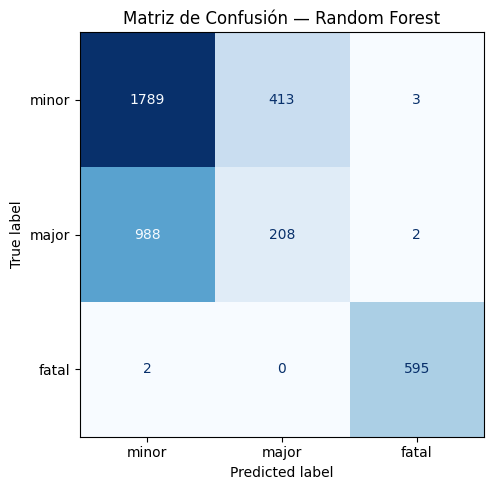

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=['minor','major','fatal'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['minor','major','fatal']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cm_random_forest.png'), dpi=110, bbox_inches='tight')
plt.show()


## 3.4 Importancia de features

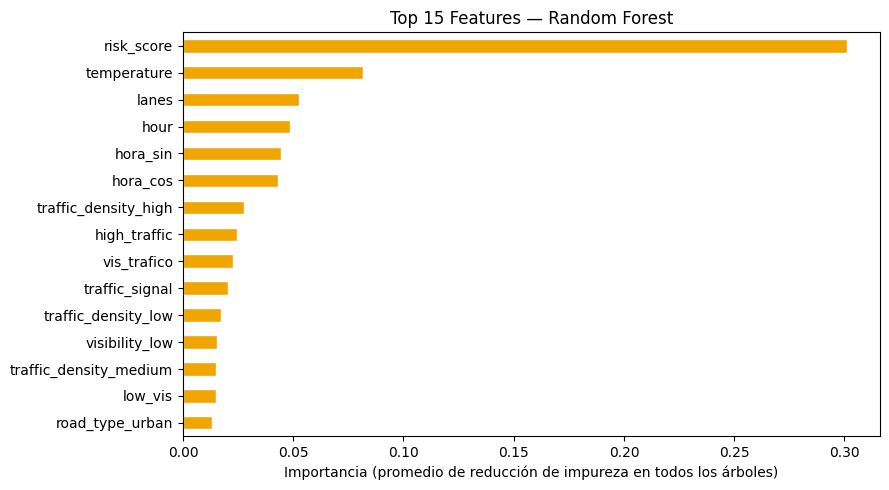

Feature,Importancia
risk_score,0.301100
temperature,0.081700
lanes,0.052800
hour,0.048600
hora_sin,0.044600
hora_cos,0.043300
traffic_density_high,0.027700
high_traffic,0.024600
vis_trafico,0.022700
traffic_signal,0.020400


In [6]:
imp = (pd.Series(rf.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind='barh', ax=ax, color='#F0A500', edgecolor='white')
ax.set_title('Top 15 Features — Random Forest')
ax.set_xlabel('Importancia (promedio de reducción de impureza en todos los árboles)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feat_imp_rf.png'), dpi=110, bbox_inches='tight')
plt.show()
display(imp.round(4).reset_index().rename(columns={'index':'Feature',0:'Importancia'}).style.set_caption('Top 15 features — Random Forest').hide(axis='index'))


## 3.5 Curva de aprendizaje

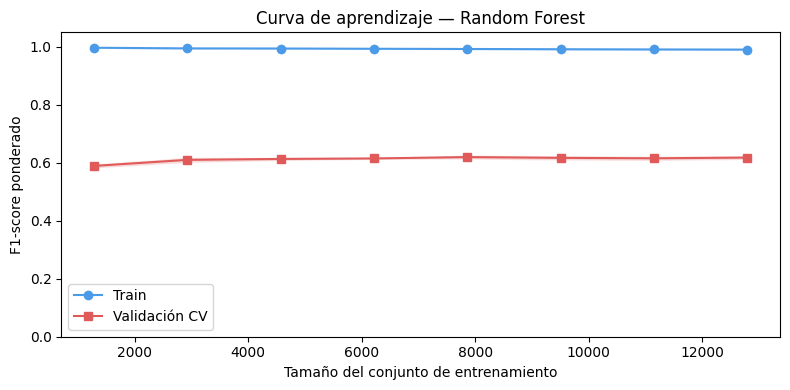

In [7]:
tr_sz, tr_sc, val_sc = learning_curve(
    rf, X_train, y_train,
    cv=CV, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_sz, tr_sc.mean(axis=1),  'o-', color='#4C9BE8', label='Train')
ax.plot(tr_sz, val_sc.mean(axis=1), 's-', color='#E05A5A', label='Validación CV')
ax.fill_between(tr_sz,
    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
    tr_sc.mean(axis=1) + tr_sc.std(axis=1), alpha=0.15, color='#4C9BE8')
ax.fill_between(tr_sz,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='#E05A5A')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-score ponderado')
ax.set_title('Curva de aprendizaje — Random Forest')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'lc_random_forest.png'), dpi=110, bbox_inches='tight')
plt.show()


La curva de aprendizaje evidencia un claro sobreajuste en el modelo Random Forest, ya que el desempeño en entrenamiento alcanza valores cercanos a 1.0, mientras que el rendimiento en la validación se mantiene alrededor de 0.62.

Esto indica que el modelo está memorizando los datos de entrenamiento en lugar de generalizar correctamente. 

## 3.6 Guardar modelo en `models/trained/`

In [8]:
ruta_pkl = os.path.join(TRAINED_DIR, 'random_forest.pkl')
joblib.dump(rf, ruta_pkl)
display(pd.DataFrame([{'Archivo':ruta_pkl,'Tamaño KB':round(os.path.getsize(ruta_pkl)/1024,1),'Estado':'Guardado'}]).style.set_caption('Modelo persistido en models/trained/').hide(axis='index'))


Archivo,Tamaño KB,Estado
c:\Users\PC\Downloads\Proyecto_ML\models\trained\random_forest.pkl,106672.900000,Guardado
